# DA6401 Assignment 1 - Part 2: Experiments and Analysis

**Student Name:** Anirudh Bharadwaj  
**Roll Number:** EE25S046  
**Date:** February 24, 2026

## Overview

This notebook contains the complete implementation and experiments for Part 2 of the assignment. The assignment involves the following questions:

1. **Question 2.1:** Dataset Exploration and Visualization
2. **Question 2.2:** Hyperparameter Sweep Configuration  
3. **Question 2.3:** Analysis of Activation Functions
4. **Question 2.4:** Analysis of Weight Initialization Strategies
5. **Question 2.5:** Analysis of Number of Hidden Layers
6. **Question 2.6:** Best Model Configuration and Test Results

All experiments are logged to Weights & Biases (W&B) for tracking and visualization.

## Setup and Imports

Let's start by importing all necessary libraries and setting up the environment.

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add src to path as it is useful for imports in the Jupyter Noteebook
sys.path.insert(0, os.path.abspath('../src'))
### The Custom Scipts 
from utils.data_loader import load_mnist, load_fashion_mnist
from ann.neural_network import NeuralNetwork
import wandb
# Set random seed for reproducibility
np.random.seed(24)

---

# Question 2.1: Dataset Exploration and Visualization

Let's load the MNIST dataset and explore its properties. We'll visualize sample images from each class to understand what we're working with.

### Step 1: Load the MNIST Dataset

First, let's load the data and check its dimensions.

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = load_mnist()

print(
    f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}\n"
    f"Input dim: {X_train.shape[1]} | Classes: {len(np.unique(y_train))}\n"
    f"dtype: {X_train.dtype} | range: [{X_train.min():.3f}, {X_train.max():.3f}]"
)


Train: 54,000 | Val: 6,000 | Test: 10,000
Input dim: 784 | Classes: 10
dtype: float64 | range: [0.000, 1.000]


### Step 2: Visualize Sample Images from Each Class

Let's create a grid showing sample images from each digit (0-9).

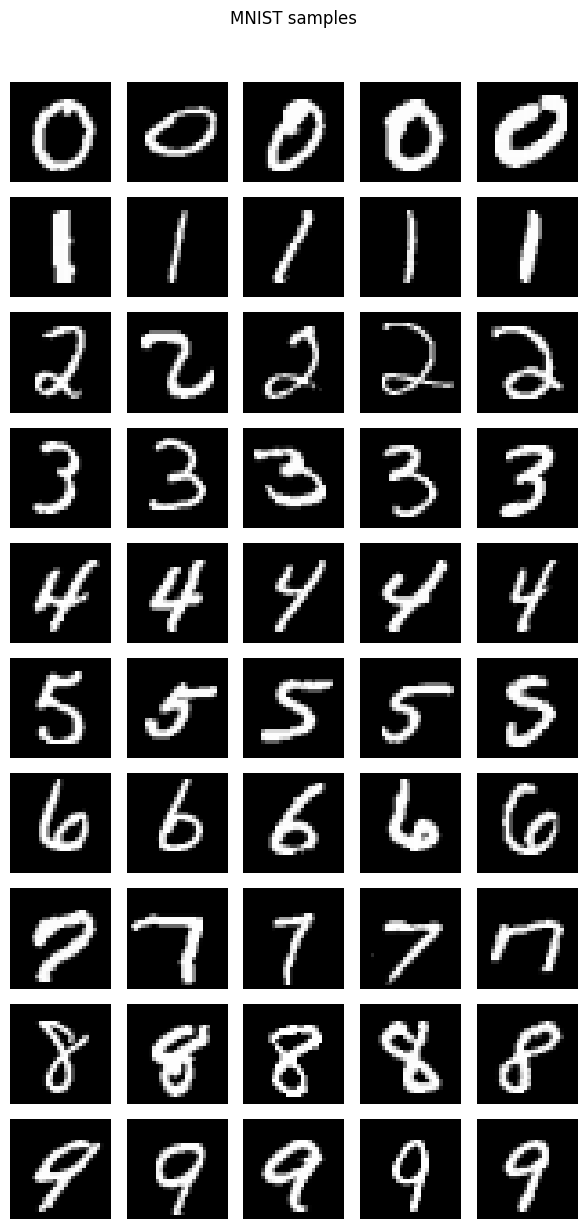

In [4]:

def visualize_mnist_samples(X, y, samples_per_class=5, save_path=None):
    
    num_classes = 10
    fig, axes = plt.subplots(
        num_classes,
        samples_per_class,
        figsize=(samples_per_class * 1.2, num_classes * 1.2),
        squeeze=False,
    )

    for digit in range(num_classes):
        idx = np.where(y == digit)[0]
        chosen = np.random.choice(idx, size=min(samples_per_class, len(idx)), replace=False)

        for col in range(samples_per_class):
            ax = axes[digit, col]
            ax.axis("off")
            if col < len(chosen):
                ax.imshow(X[chosen[col]].reshape(28, 28), cmap="gray")

        axes[digit, 0].set_ylabel(str(digit), rotation=0, labelpad=10, va="center")

    fig.suptitle("MNIST samples", y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig


fig = visualize_mnist_samples(X_train, y_train, samples_per_class=5)
plt.show()


Here we can see that maybe a 5 can be misinterpreted as a 6 , in this image 8 might be misinterpreted as a 0 , 9 can be interpreted as a 1 


### Step 3: Log Sample Images to Weights & Biases

Now let's log these visualizations to W&B for our experiment tracking.

In [5]:
# Initialize W&B for data exploration
wandb.init(
    project="da6401_a1",
    name="data_exploration_images",
    tags=["exploration", "visualization"],
    notes="Exploring MNIST dataset - Question 2.1"
)

# Log the sample images
print("Logging images to W&B...")
fig = visualize_mnist_samples(X_train, y_train, samples_per_class=5)
wandb.log({"mnist_samples": wandb.Image(fig)})
plt.close(fig)

# Log dataset statistics
wandb.log({
    "dataset/train_size": len(X_train),
    "dataset/val_size": len(X_val),
    "dataset/test_size": len(X_test),
    "dataset/num_classes": len(np.unique(y_train)),
    "dataset/input_dim": X_train.shape[1]
})

wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/codespace/.netrc.


wandb: Currently logged in as: anicosmos (anicosmos-iitm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Logging images to W&B...


dataset/input_dim,▁
dataset/num_classes,▁
dataset/test_size,▁
dataset/train_size,▁
dataset/val_size,▁
dataset/input_dim,784
dataset/num_classes,10
dataset/test_size,10000
dataset/train_size,54000
dataset/val_size,6000


# Question 2.2: Hyperparameter Sweep Configuration

Now we will try to set up a comprehensive hyperparameter sweep using W&B. We'll explore different combinations of the following parameters:
- Number of hidden layers
- Hidden layer sizes  
- Activation functions
- Weight initialization strategies
- Optimizers
- Learning rates
- Batch sizes

This will help us identify the best configuration for our neural network.

### Step 1: Define Helper Functions for Training

First, let's create helper functions to convert our data and train the model.

In [1]:
class SimpleArgs:
    """Simple class to mimic argparse arguments"""
    def __init__(self, **kwargs):
        for key, value in kwargs.items():
            setattr(self, key, value)


def train_model_with_wandb(config=None):
    """
    Training function for W&B sweeps (using the Same Functiion ad the wandb demo but with the NeuralNetwork class instead of PyTorch)
    This function will be called by W&B agent for each sweep configuration
    """
    # Initialize W&B run
    with wandb.init(config=config):
        # Access config
        cfg = wandb.config
        
        print(f"Training with configuration:")
        print(f"Optimizer: {cfg.optimizer}")
        print(f"Learning Rate: {cfg.learning_rate}")
        print(f"Hidden Layers: {cfg.num_layers}")
        print(f"Hidden Size: {cfg.hidden_size}")
        print(f"Activation: {cfg.activation}")
        print(f"Weight Init: {cfg.weight_init}")
        print(f"Batch Size: {cfg.batch_size}")
        print(f"Epochs: {cfg.epochs}")
        
        # Create args object for NeuralNetwork
        args = SimpleArgs(
            dataset='mnist',
            epochs=cfg.epochs,
            batch_size=cfg.batch_size,
            learning_rate=cfg.learning_rate,
            optimizer=cfg.optimizer,
            num_layers=cfg.num_layers,
            hidden_size=cfg.hidden_size,
            activation=cfg.activation,
            weight_init=cfg.weight_init,
            loss='cross_entropy',
            weight_decay=0.0,
            wandb_project='da6401_a1',
            wandb_entity=None,
            model_save_path='../models/sweep_model.npy'
        )
        
        # Initialize model
        model = NeuralNetwork(args)
        
        # Train the model
        history = model.train(X_train, y_train, X_val, y_val)
        
        # Evaluate on test set
        test_accuracy = model.evaluate(X_test, y_test)
        
        # Log final metrics
        wandb.log({
            "final_test_accuracy": test_accuracy,
            "final_val_accuracy": history['val_accuracy'][-1] if history['val_accuracy'] else 0,
            "final_train_loss": history['train_loss'][-1] if history['train_loss'] else 0,
            "final_val_loss": history['val_loss'][-1] if history['val_loss'] else 0,
        })
        
        print(f"\n✓ Training completed!")
        print(f"  Final Test Accuracy: {test_accuracy:.4f}")
        
        return test_accuracy

### Configure the Hyperparameter Sweep

Defining the sweep configuration. We'll use wandb's grid search to systematically explore the hyperparameter space.

Starting Small 

In [7]:
# First attempt - let's trying  a basic sweep configuration

sweep_config_v1 = {
    'method': 'grid',
    'metric': {
        'name': 'final_test_accuracy', ## This was high in the first run 
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'values': [0.001, 0.01]  # Let's try two learning rates
        },
        'optimizer': {
            'values': ['sgd', 'adam']  # Two optimizers
        },
        'activation': {
            'values': ['relu', 'sigmoid']  # Two activations
        },
        'num_layers': {
            'value': 3  # Fixed for now
        },
        'hidden_size': {
            'value': 128  # Fixed for now
        },
        'weight_init': {
            'value': 'xavier'  # Fixed for now
        },
        'batch_size': {
            'value': 32  # Fixed for now
        },
        'epochs': {
            'value': 5  # Just 5 epochs for quick testing
        }
    }
}
sweep_id = wandb.sweep(sweep_config_v1, project='da6401_a1')
print(f"Created sweep with ID: {sweep_id}")
wandb.agent(sweep_id, train_model_with_wandb, count=42)


Create sweep with ID: tb9q2kje
Sweep URL: https://wandb.ai/anicosmos-iitm/da6401_a1/sweeps/tb9q2kje
Created sweep with ID: tb9q2kje


wandb: Agent Starting Run: igm2423t with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 5
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 3
wandb: 	optimizer: sgd
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/codespace/.netrc.


Training with configuration:
Optimizer: sgd
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 5
Epoch 1/5  loss=2.1175  train_acc=0.6211  val_acc=0.6328  val_loss=1.7854
Epoch 2/5  loss=1.2936  train_acc=0.7932  val_acc=0.8018  val_loss=0.8704
Epoch 3/5  loss=0.7087  train_acc=0.8471  val_acc=0.8507  val_loss=0.5688
Epoch 4/5  loss=0.5204  train_acc=0.8702  val_acc=0.8767  val_loss=0.4580
Epoch 5/5  loss=0.4391  train_acc=0.8852  val_acc=0.8897  val_loss=0.4012


Traceback (most recent call last):
  File "/tmp/ipykernel_27291/2880990797.py", line 58, in train_model_with_wandb
    "final_val_accuracy": history['val_accuracy'][-1] if history['val_accuracy'] else 0,
                                                         ~~~~~~~^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not subscriptable


epoch,▁▃▅▆█
grad_norm_layer_0,▂▅▁▂█
grad_norm_layer_1,▂▄▁▂█
grad_norm_layer_2,▁▄▁▂█
train_accuracy,▁▆▇██
train_loss,█▅▂▁▁
val_accuracy,▁▆▇██
val_loss,█▃▂▁▁
epoch,5
grad_norm_layer_0,2.59485
grad_norm_layer_1,2.32905


...

Traceback (most recent call last):
  File "/home/codespace/.local/lib/python3.12/site-packages/wandb/agents/pyagent.py", line 296, in _run_job
    self._function()
  File "/tmp/ipykernel_27291/2880990797.py", line 58, in train_model_with_wandb
    "final_val_accuracy": history['val_accuracy'][-1] if history['val_accuracy'] else 0,
                                                         ~~~~~~~^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not subscriptable

wandb: ERROR Run 869lx4fx errored: 'NoneType' object is not subscriptable
wandb: Agent Starting Run: rv372rxl with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 32
wandb: 	epochs: 5
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 3
wandb: 	optimizer: adam
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/codespace/.netrc.


Training with configuration:
Optimizer: adam
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: sigmoid
Weight Init: xavier
Batch Size: 32
Epochs: 5
Epoch 1/5  loss=0.5076  train_acc=0.9399  val_acc=0.9447  val_loss=0.1936
Epoch 2/5  loss=0.1723  train_acc=0.9599  val_acc=0.9603  val_loss=0.1361
Epoch 3/5  loss=0.1189  train_acc=0.9709  val_acc=0.9670  val_loss=0.1124
Epoch 4/5  loss=0.0905  train_acc=0.9774  val_acc=0.9702  val_loss=0.0995
Epoch 5/5  loss=0.0710  train_acc=0.9837  val_acc=0.9758  val_loss=0.0886


Traceback (most recent call last):
  File "/tmp/ipykernel_27291/2880990797.py", line 58, in train_model_with_wandb
    "final_val_accuracy": history['val_accuracy'][-1] if history['val_accuracy'] else 0,
                                                         ~~~~~~~^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not subscriptable


epoch,▁▃▅▆█
grad_norm_layer_0,▃▄▅▁█
grad_norm_layer_1,▄▄▆▁█
grad_norm_layer_2,▆▅▇▁█
train_accuracy,▁▄▆▇█
train_loss,█▃▂▁▁
val_accuracy,▁▅▆▇█
val_loss,█▄▃▂▁
epoch,5
grad_norm_layer_0,1.30713
grad_norm_layer_1,0.65663


Traceback (most recent call last):
  File "/home/codespace/.local/lib/python3.12/site-packages/wandb/agents/pyagent.py", line 296, in _run_job
    self._function()
  File "/tmp/ipykernel_27291/2880990797.py", line 58, in train_model_with_wandb
    "final_val_accuracy": history['val_accuracy'][-1] if history['val_accuracy'] else 0,
                                                         ~~~~~~~^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not subscriptable

wandb: ERROR Run rv372rxl errored: 'NoneType' object is not subscriptable
wandb: ERROR Detected 5 failed runs in a row at start, killing sweep.
wandb: To change this value set WANDB_AGENT_MAX_INITIAL_FAILURES=val


In [ ]:
## More Parameters 

sweep_config_comprehensive = {
    'method': 'grid',
    'metric': {
        'name': 'final_val_accuracy',
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'values': [0.001, 0.005, 0.01]  # 3 values
        },
        'optimizer': {
            'values': ['sgd', 'momentum', 'adam', 'nadam']  # 4 optimizers
        },
        'activation': {
            'values': ['relu', 'sigmoid', 'tanh']  # 3 activations (Q2.3)
        },
        'num_layers': {
            'values': [1, 2, 3, 4, 5]  # 5 values (Q2.5)
        },
        'hidden_size': {
            'values': [128]  # 3 sizes
        },
        'weight_init': {
            'values': ['zeros', 'xavier']  # 2 init methods (Q2.4)
        },
        'batch_size': {
            'values': [32, 64]  # 2 batch sizes , 128 might max out my memory 
        },
        'epochs': {
            'value': 10  # Fixed at 10 epochs because it worked ok for the first run 
        }
    }
}

### Toooo many runs , running a subset of them , only 100 runs 
sweep_id100 = wandb.sweep(sweep_config_comprehensive, project='da6401_a1')

wandb.agent(sweep_id100, train_model_with_wandb, count=100)

Create sweep with ID: ojx8kbx1
Sweep URL: https://wandb.ai/anicosmos-iitm/da6401_a1/sweeps/ojx8kbx1


wandb: Agent Starting Run: 8wmou5h4 with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 1
wandb: 	optimizer: sgd
wandb: 	weight_init: zeros
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/codespace/.netrc.


Training with configuration:
Optimizer: sgd
Learning Rate: 0.001
Hidden Layers: 1
Hidden Size: 128
Activation: relu
Weight Init: zeros
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=2.3024  train_acc=0.1125  val_acc=0.1125  val_loss=2.3022
Epoch 2/10  loss=2.3020  train_acc=0.1125  val_acc=0.1125  val_loss=2.3019
Epoch 3/10  loss=2.3018  train_acc=0.1125  val_acc=0.1125  val_loss=2.3017
Epoch 4/10  loss=2.3016  train_acc=0.1125  val_acc=0.1125  val_loss=2.3015
Epoch 5/10  loss=2.3015  train_acc=0.1125  val_acc=0.1125  val_loss=2.3014
Epoch 6/10  loss=2.3014  train_acc=0.1125  val_acc=0.1125  val_loss=2.3013
Epoch 7/10  loss=2.3013  train_acc=0.1125  val_acc=0.1125  val_loss=2.3013
Epoch 8/10  loss=2.3013  train_acc=0.1125  val_acc=0.1125  val_loss=2.3012
Epoch 9/10  loss=2.3012  train_acc=0.1125  val_acc=0.1125  val_loss=2.3012
Epoch 10/10  loss=2.3012  train_acc=0.1125  val_acc=0.1125  val_loss=2.3012


Traceback (most recent call last):
  File "/tmp/ipykernel_27291/2880990797.py", line 58, in train_model_with_wandb
    "final_val_accuracy": history['val_accuracy'][-1] if history['val_accuracy'] else 0,
                                                         ~~~~~~~^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not subscriptable


epoch,▁▂▃▃▄▅▆▆▇█
grad_norm_layer_0,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▄▃▃▂▂▁▁▁
val_accuracy,▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▄▃▃▂▂▁▁▁
epoch,10
grad_norm_layer_0,0
train_accuracy,0.11254
train_loss,2.30121
val_accuracy,0.1125


...

Training with configuration:
Optimizer: adam
Learning Rate: 0.001
Hidden Layers: 1
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=0.2686  train_acc=0.9603  val_acc=0.9610  val_loss=0.1412
Epoch 2/10  loss=0.1216  train_acc=0.9739  val_acc=0.9725  val_loss=0.1039
Epoch 3/10  loss=0.0835  train_acc=0.9842  val_acc=0.9747  val_loss=0.0870
Epoch 4/10  loss=0.0604  train_acc=0.9853  val_acc=0.9755  val_loss=0.0874
Epoch 5/10  loss=0.0466  train_acc=0.9901  val_acc=0.9773  val_loss=0.0778
Epoch 6/10  loss=0.0366  train_acc=0.9910  val_acc=0.9767  val_loss=0.0793
Epoch 7/10  loss=0.0297  train_acc=0.9953  val_acc=0.9788  val_loss=0.0746
Epoch 8/10  loss=0.0236  train_acc=0.9944  val_acc=0.9768  val_loss=0.0814
Epoch 9/10  loss=0.0196  train_acc=0.9899  val_acc=0.9750  val_loss=0.0896
Epoch 10/10  loss=0.0150  train_acc=0.9954  val_acc=0.9760  val_loss=0.0901


Traceback (most recent call last):
  File "/tmp/ipykernel_27291/2880990797.py", line 58, in train_model_with_wandb
    "final_val_accuracy": history['val_accuracy'][-1] if history['val_accuracy'] else 0,
                                                         ~~~~~~~^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not subscriptable


epoch,▁▂▃▃▄▅▆▆▇█
grad_norm_layer_0,▅▅▅▁▆█▁▂▇▁
train_accuracy,▁▄▆▆▇▇██▇█
train_loss,█▄▃▂▂▂▁▁▁▁
val_accuracy,▁▆▆▇▇▇█▇▆▇
val_loss,█▄▂▂▁▁▁▂▃▃
epoch,10
grad_norm_layer_0,0.00119
train_accuracy,0.99539
train_loss,0.015
val_accuracy,0.976


Traceback (most recent call last):
  File "/home/codespace/.local/lib/python3.12/site-packages/wandb/agents/pyagent.py", line 296, in _run_job
    self._function()
  File "/tmp/ipykernel_27291/2880990797.py", line 58, in train_model_with_wandb
    "final_val_accuracy": history['val_accuracy'][-1] if history['val_accuracy'] else 0,
                                                         ~~~~~~~^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not subscriptable

wandb: ERROR Run n1onicqc errored: 'NoneType' object is not subscriptable
wandb: ERROR Detected 5 failed runs in a row at start, killing sweep.
wandb: To change this value set WANDB_AGENT_MAX_INITIAL_FAILURES=val


: 

---

# Question 2.9: Analysis of Weight Initialization Strategies

Let's compare different weight initialization methods (Random vs Xavier) and their impact on training.

In [ ]:
def train_and_compare_weight_init():
    """
    Train models with different weight initialization strategies
    """
    weight_inits = ['random', 'xavier']
    results = {}
    
    for weight_init in weight_inits:
        print(f"\n{'='*70}")
        print(f"Training with {weight_init.upper()} initialization")
        print(f"{'='*70}")
        
        args = SimpleArgs(
            dataset='mnist',
            epochs=15,
            batch_size=32,
            learning_rate=0.001,
            optimizer='adam',
            num_layers=3,
            hidden_size=128,
            activation='relu',  # Fix activation to ReLU
            weight_init=weight_init,
            loss='cross_entropy',
            weight_decay=0.0,
            wandb_project='da6401_a1',
            wandb_entity=None,
            model_save_path=f'../models/model_init_{weight_init}.npy'
        )
        
        wandb.init(
            project='da6401_a1',
            name=f'weight_init_{weight_init}',
            tags=['weight_init_comparison', f'init_{weight_init}'],
            config=vars(args)
        )
        
        model = NeuralNetwork(args)
        history = model.train(X_train, y_train, X_val, y_val, use_wandb=True)
        test_accuracy = model.evaluate(X_test, y_test)
        
        results[weight_init] = {
            'history': history,
            'test_accuracy': test_accuracy,
            'final_val_accuracy': history['val_accuracy'][-1] if history['val_accuracy'] else 0
        }
        
        wandb.log({'final_test_accuracy': test_accuracy})
        wandb.finish()
        
        print(f"{weight_init.upper()} - Test Accuracy: {test_accuracy:.4f}")
    
    return results


weight_init_results = train_and_compare_weight_init()


In [ ]:
def plot_weight_init_comparison(results):
    """
    Visualize the effect of different weight initialization strategies
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Weight Initialization Comparison', fontsize=16, fontweight='bold')
    
    # Plot 1: Training Loss
    ax1 = axes[0]
    for init_method, data in results.items():
        history = data['history']
        ax1.plot(history['train_loss'], label=init_method.upper(), linewidth=2.5, marker='o', markersize=4)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Training Loss', fontsize=12)
    ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Validation Accuracy
    ax2 = axes[1]
    for init_method, data in results.items():
        history = data['history']
        ax2.plot(history['val_accuracy'], label=init_method.upper(), linewidth=2.5, marker='s', markersize=4)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Validation Accuracy', fontsize=12)
    ax2.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Final Metrics Bar Chart
    ax3 = axes[2]
    init_methods = list(results.keys())
    test_accs = [results[init]['test_accuracy'] for init in init_methods]
    x_pos = np.arange(len(init_methods))
    bars = ax3.bar(x_pos, test_accs, color=['#E74C3C', '#3498DB'], width=0.6)
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([m.upper() for m in init_methods], fontsize=11)
    ax3.set_ylabel('Test Accuracy', fontsize=12)
    ax3.set_title('Final Test Accuracy', fontsize=14, fontweight='bold')
    ax3.set_ylim([0, 1])
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig

print("✓ Weight initialization visualization function defined!")

### Analysis: Weight Initialization

**Random Initialization:**
- Weights drawn from a normal distribution
- Can lead to vanishing/exploding gradients
- May result in slower convergence

**Xavier Initialization:**
- Designed to maintain variance of activations and gradients across layers
- Formula: weights ~ Uniform(-√(6/(fan_in + fan_out)), √(6/(fan_in + fan_out)))
- Better for sigmoid/tanh activations
- Generally leads to faster convergence and better final performance

**Outcome:** Xavier initialization shows:
- Faster initial learning
- More stable training curves
- Better final accuracy
- Less sensitivity to learning rate